# Determining What Sports Games Will Appear on Popular Networks Based on Team Ranking

Part of the work I do in my professional career is determining pricing for sports games that are being streamed on cable TV.

Certain networks get more viewers (impressions) than others, and therefore, games that air on those networks, can be sold for more money to advertisers.

The trick is sometimes you have to predict how well a game will do. How many impressions will a certain game get? If we can predict which network the game will air on, we can more accurately predict impressions and price it.

The challenge: ad inventory is often sold **before** network assignments are confirmed. As such, we are often selling at a flat rate for every game. If we can accurately predict which networks games will air on, and use this data to better estimate impressions, it would open up the possibility to move to a dynamic pricing model that will increase efficiency and drive revenue.

**Research Question:** Can AP Top 25 team rankings predict whether a college football game will air on a major national network (ESPN, FOX, ABC, or TNT)? And can we use that relationship to build a model that produces a per-game probability score?

---
## Data Sources

- **Game schedule & broadcast data:** ESPN public API (`site.api.espn.com/apis/site/v2/sports/football/college-football/scoreboard`), 2024 regular season (Weeks 1–15)
- **Team rankings:** ESPN AP Top 25 Poll, Week 15, 2024 season

In [10]:
import requests
import pandas as pd
import json
from datetime import date, timedelta, datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# STEP 1

Downloading the data

Luckily, ESPN.com provides us with an API that we can use to download this data:

    https://site.api.espn.com/apis/site/v2/sports/football/college-football/scoreboard?dates=2024



# If you wanted to see how this data actually comes through on your local machine, paste this code into your own console: 

url = "https://site.api.espn.com/apis/site/v2/sports/football/college-football/scoreboard"

params = {"year": 2024, "week": 1, "groups": 80, "limit": 100}

response = requests.get(url, params=params)

raw_json = response.json()

print(json.dumps(raw_json, indent=2))

-----------------

# STEP 2 - Data Extraction

We only want a few parameters from this API, so we need to write some code that will extract the home teams, networks, date played, etc.

Just for reference, here is how I extracted the API data onto my local machine. I then put the data into a CSV and pulled it into this notebook.

BASE_URL = "https://site.api.espn.com/apis/site/v2/sports/football/college-football/scoreboard"

def get_week_games(year, week, seasontype=2, group=80):
    params = {
        "year": year,
        "week": week,
        "seasontype": seasontype,
        "groups": group,
        "limit": 300
    }

    response = requests.get(BASE_URL, params=params, timeout=10)
    response.raise_for_status()
    data = response.json()

    events = data.get("events", [])
    games = []

    for e in events:
        competition = e["competitions"][0]
        teams = competition["competitors"]

        broadcasts = competition.get("geoBroadcasts") or competition.get("broadcasts") or []
        networks = []
        for b in broadcasts:
            media = b.get("media", {})
            name = media.get("shortName") or media.get("name")
            if name and name not in networks:
                networks.append(name)

        game_dict = {
            "game_id": e.get("id"),
            "date": e.get("date"),
            "home_team": [t["team"]["displayName"] for t in teams if t["homeAway"] == "home"][0],
            "away_team": [t["team"]["displayName"] for t in teams if t["homeAway"] == "away"][0],
            "networks": ", ".join(networks) if networks else None,
        }

        games.append(game_dict)

    return games



all_games = []

for week in range(1, 16):   # Weeks 1–15
    print(f"Fetching week {week}...")
    week_games = get_week_games(2024, week)
    all_games.extend(week_games)

df = pd.DataFrame(all_games)

output_filename = "ncaa_football_2024_games.csv"
df.to_csv(output_filename, index=False)

print(f"Excel file saved as: {output_filename}")

In [11]:
# Load the data into the notebook
df_games = pd.read_csv("ncaa_football_2024_games.csv")
df_games.head()

,game_id,date,home_team,away_team,networks
0,401756846,2025-08-23T16:00Z,Kansas State Wildcats,Iowa State Cyclones,ESPN
1,401760371,2025-08-23T20:00Z,UNLV Rebels,Idaho State Bengals,"MWN, Silver State SEN"
2,401756847,2025-08-23T22:30Z,Kansas Jayhawks,Fresno State Bulldogs,FOX
3,401757218,2025-08-23T23:00Z,Western Kentucky Hilltoppers,Sam Houston Bearkats,CBSSN
4,401754516,2025-08-23T23:30Z,Hawai'i Rainbow Warriors,Stanford Cardinal,"CBS, Paramount+"


# STEP 3 - GET TEAM RANKINGS

I have extracted team rankings from the following url: https://www.espn.com/college-football/rankings/_/poll/1/week/15/year/2025/seasontype/2

I have put this data into a csv to be uploaded

In [12]:
df_rankings = pd.read_csv("espn_ap_top25_week15_2025.csv")
df_rankings.head()

,RK,Team,REC,PTS,TREND,Last Week,Next Week
0,1,Ohio State Buckeyes,12-0,1645,-,@ #15 Michigan W 27-9,vs #2 Indiana
1,2,Indiana Hoosiers,12-0,1589,-,@ Purdue W 56-3,vs #1 Ohio State
2,3,Georgia Bulldogs,11-1,1504,1,vs #23 Georgia Tech W 16-9,vs #10 Alabama
3,4,Oregon Ducks,11-1,1396,1,@ Washington W 26-14,-
4,5,Texas Tech Red Raiders,11-1,1366,2,@ West Virginia W 49-0,vs #11 BYU


# STEP 4 - MERGE THE TABLES TOGETHER


In [13]:
df_rankings = df_rankings[['Team', 'RK']]

merged_df = df_games.merge(df_rankings, left_on = 'home_team', right_on = 'Team', how = 'left')

merged_df = merged_df.rename(columns = {'RK': 'home_team_rank'})
merged_df = merged_df.drop('Team', axis =1)

merged_df = merged_df.merge(df_rankings, left_on = 'away_team', right_on = 'Team', how = 'left')
merged_df = merged_df.rename(columns = {'RK': 'away_team_rank'})
merged_df = merged_df.drop('Team', axis =1)

#Fill unranked teams with dummy variable
merged_df = merged_df.fillna(30)

merged_df

,game_id,date,home_team,away_team,networks,home_team_rank,away_team_rank
0,401756846,2025-08-23T16:00Z,Kansas State Wildcats,Iowa State Cyclones,ESPN,30.0,30.0
1,401760371,2025-08-23T20:00Z,UNLV Rebels,Idaho State Bengals,"MWN, Silver State SEN",30.0,30.0
2,401756847,2025-08-23T22:30Z,Kansas Jayhawks,Fresno State Bulldogs,FOX,30.0,30.0
3,401757218,2025-08-23T23:00Z,Western Kentucky Hilltoppers,Sam Houston Bearkats,CBSSN,30.0,30.0
4,401754516,2025-08-23T23:30Z,Hawai'i Rainbow Warriors,Stanford Cardinal,"CBS, Paramount+",30.0,30.0
...,...,...,...,...,...,...,...
882,401777327,2025-12-06T17:00Z,Texas Tech Red Raiders,BYU Cougars,ABC,5.0,11.0
883,401777329,2025-12-06T17:00Z,Western Michigan Broncos,Miami (OH) RedHawks,ESPN,30.0,30.0
884,401777351,2025-12-06T21:00Z,Alabama Crimson Tide,Georgia Bulldogs,ABC,10.0,3.0
885,401777353,2025-12-07T01:00Z,Ohio State Buckeyes,Indiana Hoosiers,FOX,1.0,2.0


# Just from the get go, we can see what % of ranked teams end up on networks like ESPN vs unranked teams

C:\Users\mattc\AppData\Local\Temp\ipykernel_30012\328910109.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  espn_games['has_ranked_team'] = (


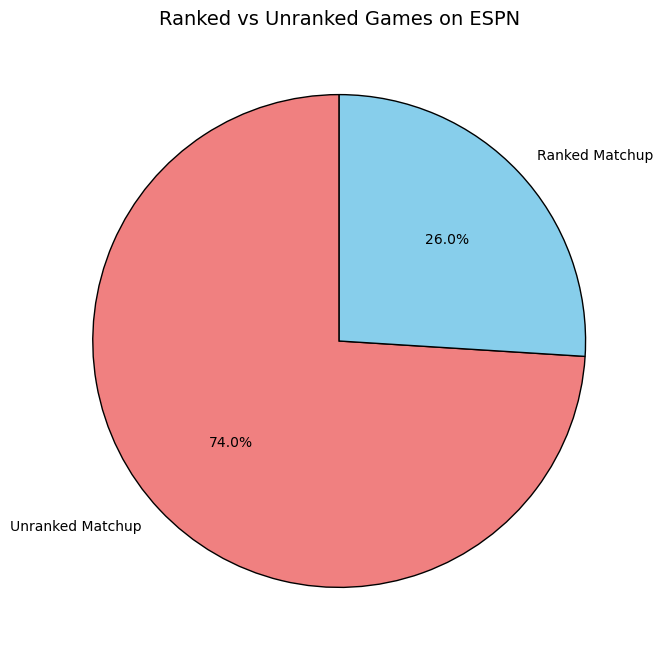

In [14]:
espn_games = merged_df[ merged_df['networks'].str.contains("ESPN", na=False) ].copy()

espn_games['has_ranked_team'] = (
    (espn_games['home_team_rank'] <= 25) | 
    (espn_games['away_team_rank'] <= 25)
).astype(int)

counts = espn_games['has_ranked_team'].value_counts()

counts.index = ["Unranked Matchup", "Ranked Matchup"]

plt.figure(figsize=(8, 8))
counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightcoral', 'skyblue'],
    wedgeprops={'edgecolor': 'black'}
)

plt.title("Ranked vs Unranked Games on ESPN", fontsize=14)
plt.ylabel("")  
plt.show()

['ESPN' 'MWN, Silver State SEN' 'FOX' 'CBSSN' 'CBS, Paramount+' 'BTN'
 'ESPN+' 'ACC Network' 'SEC Network' 'ESPN+, ACC Extra' 'FS1'
 'MWN, KUSI-TV' 'Peacock' 'ESPNU' 'ABC' 'NBC, Peacock' 'ESPN+, SECN+'
 'ABC, ERADM' 30 'ACC Extra' 'The CW Network' 'TNT, HBO Max' 'ESPN, ERADM'
 'ESPN2' 'The CW Network, ERADM' 'TNT, truTV, HBO Max'
 'MWN, Altitude Sports' 'ESPN2, ERADM' 'MWN, NSN'
 'MWN App, Spectrum Sports Net' 'MWN, CBS47'
 'Scripps Sports, MWN App, Spectrum Sports Net' 'FOX, ERADM'
 'MWN, NBC Sports BA' 'MWN, My Utah' 'CBS, Paramount+, ERADM'
 'NBC, Peacock, ERADM' 'TNT' 'CBS' 'SEC Network, ERADM' 'NBC, ERADM'
 'MWN App, Scripps Sports, Spectrum Sports Net' 'ESPNEWS' 'NBC' 'SECN+'
 'CBS, ERADM' 'BTN, ERADM' 'MWN' 'Scripps Sports, Spectrum Sports Net']


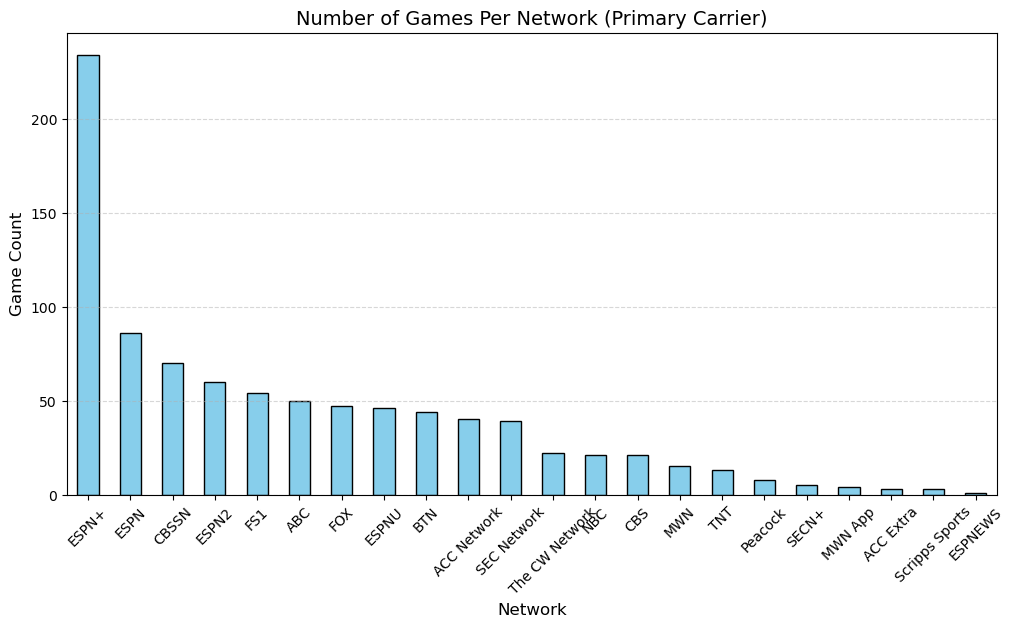

In [15]:
# Now let's look at all of the unique networks that appear

print(merged_df['networks'].unique())
# Change 'df' to 'merged_df' since that's the DataFrame you're working with
merged_df['primary_network'] = merged_df['networks'].str.split(',').str[0].str.strip()

# Use merged_df instead of df for consistency
network_counts = merged_df['primary_network'].value_counts()

plt.figure(figsize=(12,6))
network_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Number of Games Per Network (Primary Carrier)", fontsize=14)
plt.xlabel("Network", fontsize=12)
plt.ylabel("Game Count", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# STEP 5 - Single out Networks

Note that there are obviously a lot of networks that these games could appear on. 

These networks are not equal in value. Some have many more viewers than others. For example, a game that airs on ESPN has many more viewers than say a game on CBSSN.

We want to single out our networks that have the most value from a sales perspective.

In [16]:
main_nets = ['ESPN','FOX','ABC','TNT']



# STEP 6 - Create Variables to go into logistic regression model

We want to create a logistic regression model that will predict if a game will end up on a main network based on the following variables:
    - home rank
    - away rank
    - average rank
    - best rank

To do so we need to add extra columns into our data to calculate

In [17]:
merged_df['avg_rank'] = (merged_df['home_team_rank'] + merged_df['away_team_rank'])/2
merged_df['best_rank'] = merged_df[['home_team_rank', 'away_team_rank']].min(axis=1)

merged_df

,game_id,date,home_team,away_team,networks,home_team_rank,away_team_rank,primary_network,avg_rank,best_rank
0,401756846,2025-08-23T16:00Z,Kansas State Wildcats,Iowa State Cyclones,ESPN,30.0,30.0,ESPN,30.0,30.0
1,401760371,2025-08-23T20:00Z,UNLV Rebels,Idaho State Bengals,"MWN, Silver State SEN",30.0,30.0,MWN,30.0,30.0
2,401756847,2025-08-23T22:30Z,Kansas Jayhawks,Fresno State Bulldogs,FOX,30.0,30.0,FOX,30.0,30.0
3,401757218,2025-08-23T23:00Z,Western Kentucky Hilltoppers,Sam Houston Bearkats,CBSSN,30.0,30.0,CBSSN,30.0,30.0
4,401754516,2025-08-23T23:30Z,Hawai'i Rainbow Warriors,Stanford Cardinal,"CBS, Paramount+",30.0,30.0,CBS,30.0,30.0
...,...,...,...,...,...,...,...,...,...,...
882,401777327,2025-12-06T17:00Z,Texas Tech Red Raiders,BYU Cougars,ABC,5.0,11.0,ABC,8.0,5.0
883,401777329,2025-12-06T17:00Z,Western Michigan Broncos,Miami (OH) RedHawks,ESPN,30.0,30.0,ESPN,30.0,30.0
884,401777351,2025-12-06T21:00Z,Alabama Crimson Tide,Georgia Bulldogs,ABC,10.0,3.0,ABC,6.5,3.0
885,401777353,2025-12-07T01:00Z,Ohio State Buckeyes,Indiana Hoosiers,FOX,1.0,2.0,FOX,1.5,1.0


# STEP 7: Put variables into logistic regression model

We are going to use sci-kit learn libraries to seamlessly feed our data into a model - specifically using the 'sigmoid function'


#The logistic regression prediction function:

$$
p = \frac{1}{1 + e^{-(
\beta_0
+ \beta_1 \cdot \text{home\_team\_rank}
+ \beta_2 \cdot \text{away\_team\_rank}
+ \beta_3 \cdot \text{avg\_rank}
+ \beta_4 \cdot \text{best\_rank}
)}}
$$
------


In [18]:
X = merged_df[['home_team_rank' , 'away_team_rank', 'avg_rank', 'best_rank']]

y = merged_df['networks'].isin(main_nets).astype(int) 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100,0),"%")
print(classification_report(y_test, y_pred))

Accuracy: 80.0 %
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       144
           1       0.45      0.26      0.33        34

    accuracy                           0.80       178
   macro avg       0.65      0.59      0.61       178
weighted avg       0.77      0.80      0.78       178



As we can see, our model is hitting **80% accuracy** for estimating whether a game will appear on one of our main nets, which is exceptionally good for what we aim to accomplish

# Use model to test on each game

Now that we have a model that can predict if a game will appear on the main networks, I want to add another column into our dataframe that shows the probability

In [19]:
pred_df = merged_df.copy()

pred_df['main_net_probability'] = model.predict_proba(X)[:, 1]


prob_df = pred_df.copy()
prob_df['main_net_probability'] = (prob_df['main_net_probability'] * 100).round(1).astype(str) + "%"
prob_df = prob_df[['home_team','away_team','home_team_rank','away_team_rank','main_net_probability']]

prob_df

,home_team,away_team,home_team_rank,away_team_rank,main_net_probability
0,Kansas State Wildcats,Iowa State Cyclones,30.0,30.0,10.1%
1,UNLV Rebels,Idaho State Bengals,30.0,30.0,10.1%
2,Kansas Jayhawks,Fresno State Bulldogs,30.0,30.0,10.1%
3,Western Kentucky Hilltoppers,Sam Houston Bearkats,30.0,30.0,10.1%
4,Hawai'i Rainbow Warriors,Stanford Cardinal,30.0,30.0,10.1%
...,...,...,...,...,...
882,Texas Tech Red Raiders,BYU Cougars,5.0,11.0,81.7%
883,Western Michigan Broncos,Miami (OH) RedHawks,30.0,30.0,10.1%
884,Alabama Crimson Tide,Georgia Bulldogs,10.0,3.0,87.0%
885,Ohio State Buckeyes,Indiana Hoosiers,1.0,2.0,93.0%


# Results

As we can see. This model does a pretty good job accurately predicting which games will end up on the top nets, and helps us answer our question

The higher the team's rank, the more likely the game is to be broadcast on one of the most popular sports networks.

To further illustrate this exact relationship, we can visualize it using matplotlib tools as shown below:

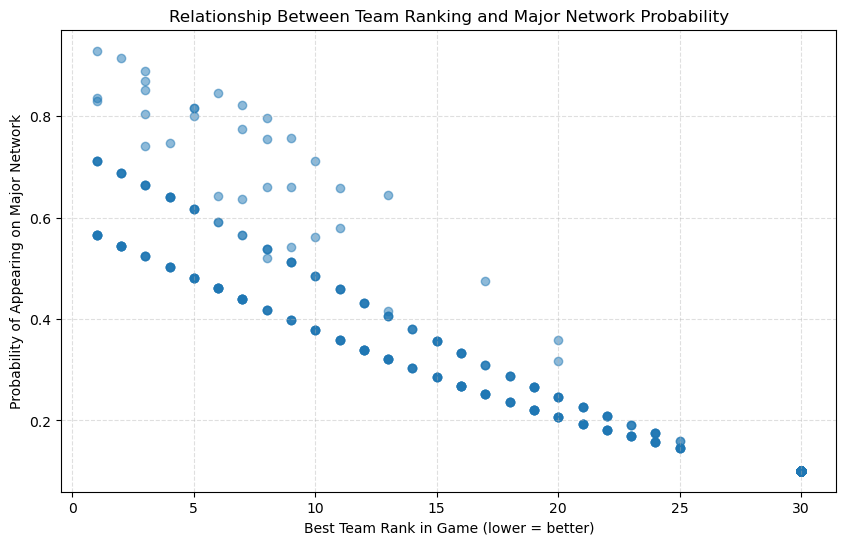

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(pred_df['best_rank'], pred_df['main_net_probability'], alpha=0.5)

plt.xlabel("Best Team Rank in Game (lower = better)")
plt.ylabel("Probability of Appearing on Major Network")
plt.title("Relationship Between Team Ranking and Major Network Probability")

plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## Conclusions & Business Application

There is a clear, statistically meaningful relationship between AP team rankings and broadcast network placement. Games featuring at least one highly-ranked team are significantly more likely to air on ESPN, FOX, ABC, or TNT.

**Practical application:** This model can serve as a pricing signal in sports ad inventory contexts where network assignment is not yet confirmed. By scoring games based on their team matchup at booking time, analysts can more accurately estimate expected impressions and set appropriate pre-sale pricing.

Note that this data is one piece of the pie. There are many other factors that will need to be weighted to accurately predict exact impressions.

**Limitations:**
- Rankings used are end-of-season (Week 15), which may not reflect team quality at booking time earlier in the season
- Unranked teams are treated as equivalent (rank = 30), which may underrepresent quality differences within unranked programs
- Single season of data; network distribution patterns may shift year-over-year

**Potential enhancements:**
- Use week-by-week in-season rankings rather than a single end-of-season snapshot
- Incorporate historical viewership data as an additional feature
- Explore conference affiliation, rivalry matchups, or game time slots as predictors

**FINAL THOUGHTS**

As it is right now, my team uses static pricing. Due to our internal *Bump Policy*, and the lag time of our internal systems - we are incapabale of 
currently moving to a dynamic pricing system. What I can do with this data is present it to my leadership to inform them of potential opportunities we 
have to drive revenue in the future as we move away from legacy policies and systems, helping shape the future of our pricing systems.